# Activity 5.2 Topic Modeling

#### Objective(s):

This activity aims to introduce how to use LDA for topic modeling

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to preprocess words in the dataset.
* Demonstrate how to create and build LDA model using specified number of topics

#### Resources:
* Jupyter Notebook
* fetch20 dataset

#### Procedures
Load the necessary libraries and datasets

Remove the headers, footers, and quotes from each member of the set

In [1]:
import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)
import numpy as np
import nltk
import os
from sklearn import datasets



The following code block loads the 20 Newsgroups dataset but only 3 categories, namely "atheism", "graphics", and "baseball".

The remove= parameter strips out email headers, footers, and quoted replies so only the actual message body remains, giving cleaner text for modeling.

In [2]:
categories = ['alt.atheism', 'comp.graphics', 'rec.sport.baseball']
ng_train = datasets.fetch_20newsgroups(subset='train',
                                       categories=categories,
                                       remove=('headers',
                                               'footers', 'quotes'))

To check the contents, we take a peek at the raw document entries

In [3]:
print(ng_train.data[2])
print("++\n", ng_train.data[1504])
print("++\n", ng_train.data[1000])



	Sorry, I was, but I somehow have misplaced my diskette from the last 
couple of months or so. However, thanks to the efforts of Bobby, it is being 
replenished rather quickly!  

	Here is a recent favorite:

	--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "

        S.N. Mozumder (snm6394@ultb.isc.rit.edu) 


--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "
++
 

Why not use the PD C library for reading/writing TIFF files? It took me a
good 20 minutes to start using them in your own app.

Martin

--
---------------------------------------------------------------------------
++
 
Indeed, if the color teal on a team's uniforms is any indication of the
future, the Marlins are in dire trouble! Refer to the San Jose Sharks for
proof... But I have hope for the Marlins. I was a sometime member of the
Rene Lachemann fan club at the Oakland Coliseum, and have a deep respect
for the guy

* Pre-process all words in your document, including removing stop words.
* Remove words that show up in more than 60% of the documents/
* Vectorize your documents using NGrams

The following code block then converts the text documents into a matrix of word counts

**ngram_range** captures single words and two-word phrases as one feature <br>
**stop_words** removes common english words <br>
**token_pattern** functions to keep words with 2+ lowercase letters (filters out single letters and numbers) <br>
**max_df** ignores words that appear too often to be meaningful. In this case, the threshold is 60% of the documents.


In [4]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 2),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(ng_train.data)

* Create an LDA model with 3 topics. You can do this with GenSim or SkLearn.
* Print out the topics and the 20 words most associated with that topic.
* Try using more or less topics, is there a sweet spot that allows us to separate out the three input classes?
* Find a document that is clearly about baseball, does the model choose it as dominantly the topic?
* Use pyLDAvis (pip install pyldavis) to create an interactive visualization of the topics

In [5]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 4 #find 4 topics in the documents
n_iter = 10 #pass through the data 10 times to refine its topic assignments

#building the model
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online') #process documents in small batches
data = lda.fit_transform(X)
data[0]

array([0.00246896, 0.00251041, 0.99253159, 0.00248904])

The following code block prints the actual text of document 0 (the first entry in the data) to verify whether LDA's topic assignment makes sense. In this case, the text's topic is mainly baseball, which matches topic 3 (baseball)

In [6]:
print(ng_train.data[0]) # 99% composed of topic 3!




I happen to be a big fan of Jayson Stark.  He is a baseball writer for the 
Philadelphia Inquirer.  Every tuesday he writes a "Week in Review" column.  
He writes about unusual situations that occured during the week.  Unusual
stats.  He has a section called "Kinerisms of the Week" which are stupid
lines by Mets brodcaster Ralph Kiner.  Every year he has the LGTGAH contest.
That stands for "Last guy to get a hit."  He also writes for Baseball 
America.  That column is sort of a highlights of "Week in Review."  If you 
can, check his column out sometime.  He might make you laugh.

Rob Koffler



In [7]:
def display_topics(model, feature_names, no_top_words):
    for ix, topic in enumerate(model.components_):
        print("Topic ", ix)
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda,count_vectorizer.get_feature_names_out(),20)

Topic  0
jesus matthew said people den col prophecy int away war men messiah den den radius prophet row isaiah psalm row col sea
Topic  1
don god people does just think know like jpeg atheism say image time good believe way use atheists file religion
Topic  2
year game good team think don just games like players better runs hit won league time baseball season win pitching
Topic  3
graphics image edu data mail software ftp pub available send images package computer information use files thanks program processing code


* Open a new dataset from dap_split.txt
* Split this raw file into a set of documents. There is a clear marker between each article.
* Clean the text data and prepare for modeling (note that each document has some <XYZ> tags as well as extra spaces)

In [8]:
from google.colab import drive
drive.mount('/content/drive')

txt_data = "/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/hoa8.2/ap.txt"

Mounted at /content/drive


Data cleaning  by removing any line that contains an XML/HTML tag, then joins the remaining lines, lowercases everything, and removes backticks and apostrophes.

In [9]:
with open(txt_data ,'r') as f:
    raw_text = f.read()
docs = raw_text.split('---')
docs[1]

"\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP901021-0008 </DOCNO>\n<TEXT>\n Here are the winning numbers picked Saturday night for the California Lottery's twice-weekly ``Lotto 6-53'' game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP900518-0012 </DOCNO>\n<TEXT>\n A three-judge federal panel on Thursday upheld the authority of the U.S. Army Corps of Engineers to determine the level of discharges from a Missouri River reservoir in South Dakota and North Dakota. The 8th U.S. Circuit Court of Appeals panel overturned a lower court order that releases from the Oahe reservoir be reduced, as had been requested by the drought-stricken states. The appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. In a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. The tug-of-war over water rights pitted the corps and the states of Iowa, Nebraska, Kansas and Missou

In [10]:
import re
match = re.compile("<[^>]*>").search
for i,doc in enumerate(docs):
    final = []
    temp = doc.split('\n')
    for line in temp:
        if not match(line):
            final.append(line)
    docs[i] = ' '.join(final).strip().lower().replace("`","").replace("'","")
docs[1]

'here are the winning numbers picked saturday night for the california lotterys twice-weekly lotto 6-53 game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.  a three-judge federal panel on thursday upheld the authority of the u.s. army corps of engineers to determine the level of discharges from a missouri river reservoir in south dakota and north dakota. the 8th u.s. circuit court of appeals panel overturned a lower court order that releases from the oahe reservoir be reduced, as had been requested by the drought-stricken states. the appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. in a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. the tug-of-war over water rights pitted the corps and the states of iowa, nebraska, kansas and missouri against north dakota, south dakota and montana over whether water flow should be reduced from the reservoir, which stretches from pierre

In [11]:
print(len(docs))

37


Do LDA modeling to find topics in this chain of articles. Try many different numbers of topics and processing techniques.

Vectorization of the documents. Unlike before, this can now capture 3-word phrases

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 3),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(docs)

Building LDA

In [13]:
from sklearn.decomposition import LatentDirichletAllocation
n_topics = 25
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)

Displaying the topics and most common words used in each topic



In [14]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        if not topic_names or not topic_names[ix]:
            print("\nTopic ", ix)
        else:
            print("\nTopic: '",topic_names[ix],"'")
        print(", ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
display_topics(lda,count_vectorizer.get_feature_names_out(),20) # We have to look at the topics before hand and then add the labels afterwards


Topic  0
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic  2
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic  4
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic  5
people, year, million, percent, government, time, police, states, thursday, state, today, soviet, officials, years, city, billion, 

Catgorize the groups formed via LDA into specific named topic groups

In [15]:
tn = ["Political Media",None,"Financials",None,"Nordstrom Scandal","Oil","Hurricanes","North Korea","NASA","US Politics","TV Networks","Forest Fires",
      None,"Agriculture/Drought","Middle East","US Political Campaigns","Pollution","Carribean","Health/Medical","Theatre/Arts","Global Warming",
      "Advertisements","Southern US Weather","South America",None]
display_topics(lda,count_vectorizer.get_feature_names_out(),20,topic_names=tn)


Topic: ' Political Media '
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic: ' Financials '
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic: ' Nordstrom Scandal '
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic: ' Oil '
people, year, million, percent, government, time, police, states, thursday

* Either add a short analysis per code block
* Add a synthesis for the procedures at the end of the Procedure Section




The tasks in the procedure demonstrate how LDA works and how it helps in categorizing data that is unstructured, such as text. This is made possible with the help of vectorizers, which convert text data into structured data, so that it can be understood by computer models and algorithms for interpretation.

#### Supplementary Activity

* Use your own dataset
* Perform preprocessing of words in the dataset
* Create LDA model using a specified number of topics
* Show at least 2 examples of datapoints for each topic
* Plot the clustering of topics, for example the pipeline can be TruncatedSVD, KMeans, TSNE plotted via a Scatter plot.

In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


##### Load dataset



In [17]:
from google.colab import drive
drive.mount('/content/drive')
import os
data = []
path = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/hoa8.2/BBC News Summary/News Articles'

print(os.listdir(path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['tech', 'entertainment', 'business', 'sport', 'politics']


In [18]:
# dataset is in .txt files, so, I had to convert them into something that can be made into a dataframe
for category in os.listdir(path):
    cat_path = os.path.join(path, category)
    if os.path.isdir(cat_path):
        for filename in os.listdir(cat_path):
            filepath = os.path.join(cat_path, filename)
            with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
                content = f.read()
            data.append({'category': category, 'content': content})

df = pd.DataFrame(data)
print(df.shape)
print(df['category'].value_counts())
df.head()

(2225, 2)
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


,category,content
0,tech,"Rich pickings for hi-tech thieves\n\nViruses, ..."
1,tech,Supercomputer breaks speed record\n\nThe US is...
2,tech,Mobiles rack up 20 years of use\n\nMobile phon...
3,tech,China 'blocks Google news site'\n\nChina has b...
4,tech,Britons growing 'digitally obese'\n\nGadget lo...


##### Data Preprocessing

In [19]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'<[^>]*>', '', text)          # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)    # remove special chars & numbers
    text = re.sub(r'\s+', ' ', text).strip()     # collapse whitespace
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['cleaned'] = df['content'].map(preprocess)

# Preview before vs after
print("ORIGINAL:\n", df['content'].iloc[0][:300])
print("\nCLEANED:\n", df['cleaned'].iloc[0][:300])

ORIGINAL:
 Rich pickings for hi-tech thieves

Viruses, trojans and other malicious programs sent on to the net to catch you out are undergoing a subtle change.

The shift is happening as tech savvy criminals turn to technology to help them con people out of cash, steal valuable data or take over home PCs. Viru

CLEANED:
 rich pickings tech thieves viruses trojans malicious programs sent net catch undergoing subtle change shift happening tech savvy criminals turn technology help con people cash steal valuable data take home pcs viruses written make headlines infecting millions getting rarer instead programs crafted d


#### Vectorization

In [20]:
count_vectorizer = CountVectorizer(
    ngram_range=(1, 2),          # unigrams and bigrams
    stop_words='english',
    token_pattern=r'\b[a-z][a-z]+\b',
    lowercase=True,
    max_df=0.6,                  # ignore words in >60% of docs
    min_df=5                     # ignore words in <5 docs
)

X = count_vectorizer.fit_transform(df['cleaned'])
print("Matrix shape:", X.shape)

Matrix shape: (2225, 13583)


#### Building the LDA model

In [21]:
n_topics = 5   # 5 because BBC has 5 known categories

lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=15,
    random_state=42,
    learning_method='online'
)

doc_topic_matrix = lda.fit_transform(X)
print("Doc-topic matrix shape:", doc_topic_matrix.shape)
# Each row = one article, each column = probability of that topic

Doc-topic matrix shape: (2225, 5)


#### Displaying the top words per topic

In [22]:
def display_topics(model, feature_names, no_top_words):
    for ix, topic in enumerate(model.components_):
        print(f"\nTopic {ix}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda, count_vectorizer.get_feature_names_out(), 15)


Topic 0:
people mobile technology music digital users phone net use million service new data internet broadband

Topic 1:
game new games time like year club players play good going world people make team

Topic 2:
people government labour party election blair new minister told public howard plans say bbc tory

Topic 3:
best year film win world england second time number wales new ireland awards music set

Topic 4:
year brown tax economy government new market company economic growth firm bank chancellor budget oil


#### Showing two example documents per topic

In [26]:
# Print 2 examples per actual category
for category in df['category'].unique():
    print(f"\n{'='*60}")
    print(f"CATEGORY: {category.upper()}")
    print(f"{'='*60}")
    examples = df[df['category'] == category].head(2)
    for i, row in examples.iterrows():
        print(f"\n[Article {i}]")
        print(row['content'][:300], "...")



CATEGORY: TECH

[Article 0]
Rich pickings for hi-tech thieves

Viruses, trojans and other malicious programs sent on to the net to catch you out are undergoing a subtle change.

The shift is happening as tech savvy criminals turn to technology to help them con people out of cash, steal valuable data or take over home PCs. Viru ...

[Article 1]
Supercomputer breaks speed record

The US is poised to push Japan off the top of the supercomputing chart with IBM's prototype Blue Gene/L machine.

It is being assembled for the Lawrence Livermore National Laboratory, a US Department of Energy (DOE) lab. DOE test results show that Blue Gene/L has m ...

CATEGORY: ENTERTAINMENT

[Article 401]
US TV cuts nudity from BBC film

A US TV network is editing BBC Films' Dirty War to avoid showing the front of a nude woman being scrubbed down after a fictional chemical attack.

It is not worth showing "non-essential" nude scenes when indecency complaints are "aggressively pursued" by US TV watchd ...

[A

#### Visualization

After SVD: (2225, 50)


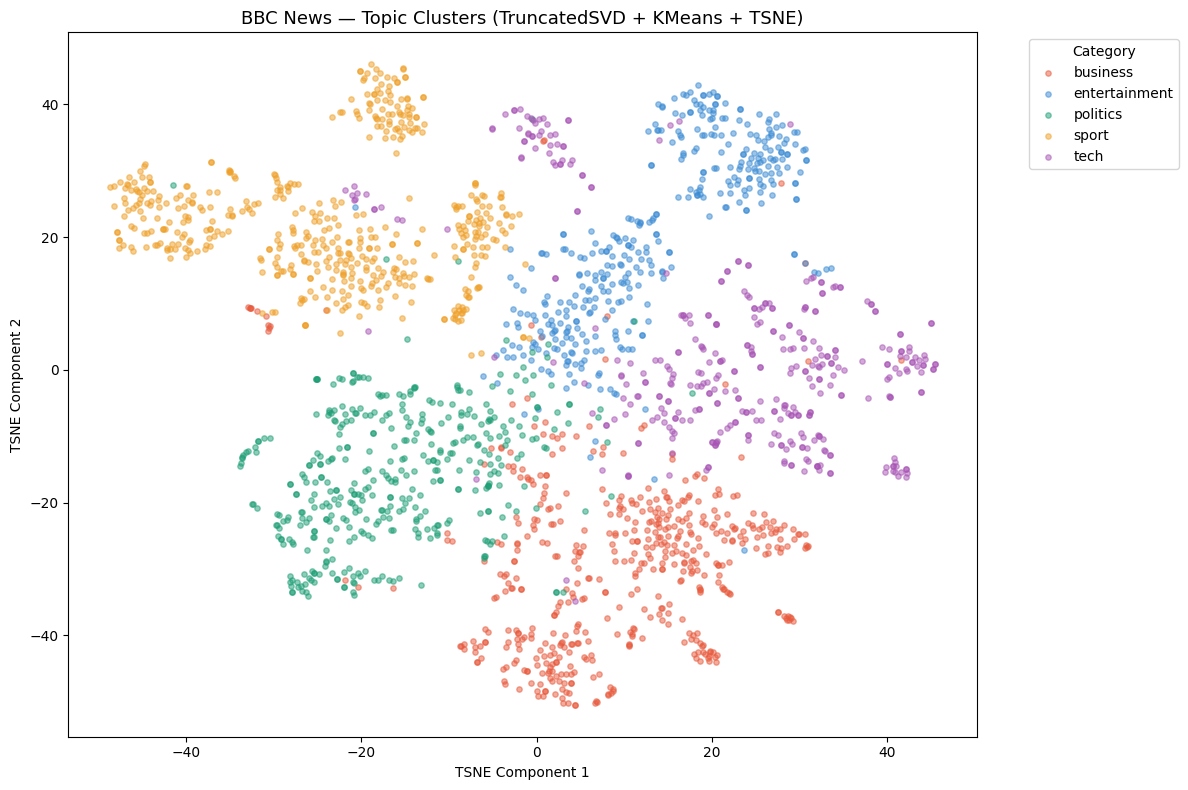

In [27]:
# Step 8a: Reduce dimensions with TruncatedSVD (50 components)
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X)
print("After SVD:", X_svd.shape)

# Step 8b: Cluster with KMeans
kmeans = KMeans(n_clusters=n_topics, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_svd)

# Step 8c: Reduce to 2D with TSNE for plotting
tsne = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=1000)
X_tsne = tsne.fit_transform(X_svd)

# Step 8d: Scatter plot
colors = ['#E8593C', '#3B8BD4', '#1D9E75', '#EF9F27', '#A855B5']
category_list = df['category'].tolist()
unique_cats = sorted(df['category'].unique())

plt.figure(figsize=(12, 8))
for i, cat in enumerate(unique_cats):
    mask = df['category'] == cat
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=colors[i], label=cat, alpha=0.5, s=15)

plt.title('BBC News — Topic Clusters (TruncatedSVD + KMeans + TSNE)', fontsize=13)
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('bbc_topic_clusters.png', dpi=150)
plt.show()

#### Conclusion

In this activity, I was able to learn the different ways to preprocess text data by using vectorizers to convert unstructured text data into structured data which can be interpreted by machine learning models.

Additionally, I was able to learn how an LDA works to categorize text based on their vectorized features. The tasks allowed me to demonstrate such functionality by creating and building an LDA model for a dataset.